In [ ]:
cd ../..

/


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install matplotlib_scalebar

In [3]:
import sys, os
save_dir = '/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/results/Recon_InP_CuCrS2P6_72/'
os.makedirs(save_dir, exist_ok=True)
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D"


if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path:", PROJECT_ROOT)

print("Project root content:", os.listdir(PROJECT_ROOT))

Added to sys.path: /content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D
Project root content: ['Notebooks', 'data', 'Magnetisation']


In [4]:
import numpy as np
# 兼容补丁 / Compatibility patch
if not hasattr(np, "int"):
  np.int = int

In [5]:
from Magnetisation.Propagator import Propagator
from Magnetisation.Generator import generator_CNN
from Magnetisation.Train import Magnetisation_CNN_training
from Magnetisation.utils import LoadData,SaveDictToJson

import numpy as np
import json
import torch
import matplotlib.pyplot as plt

[[ 1.20967962e-05  1.27617693e-05 -1.11604067e-06 ...  6.12373672e-07
  -9.27408680e-06  3.36006622e-06]
 [-2.35351561e-06  1.90742400e-05  1.16726203e-05 ...  7.14790635e-06
   3.81518691e-06  1.85042817e-05]
 [ 1.11847610e-05  5.03840452e-06  8.91404831e-06 ... -1.10155530e-05
   3.12211975e-06  3.31164806e-06]
 ...
 [-1.27712702e-05  5.44035083e-05  6.48745684e-05 ... -4.16698783e-06
  -3.09827002e-07 -9.55690083e-06]
 [ 2.47457133e-05 -8.14625736e-06  2.12731158e-05 ... -9.84392232e-06
  -2.33117399e-05 -6.44602335e-06]
 [ 4.66480968e-05  6.48932604e-05 -4.02735968e-05 ... -2.05159092e-06
  -9.31281375e-06 -8.57143705e-06]]
[[ 1.20967962e-05  1.27617693e-05 -1.11604067e-06 ...  6.12373672e-07
  -9.27408680e-06  3.36006622e-06]
 [-2.35351561e-06  1.90742400e-05  1.16726203e-05 ...  7.14790635e-06
   3.81518691e-06  1.85042817e-05]
 [ 1.11847610e-05  5.03840452e-06  8.91404831e-06 ... -1.10155530e-05
   3.12211975e-06  3.31164806e-06]
 ...
 [-1.27712702e-05  5.44035083e-05  6.4874568

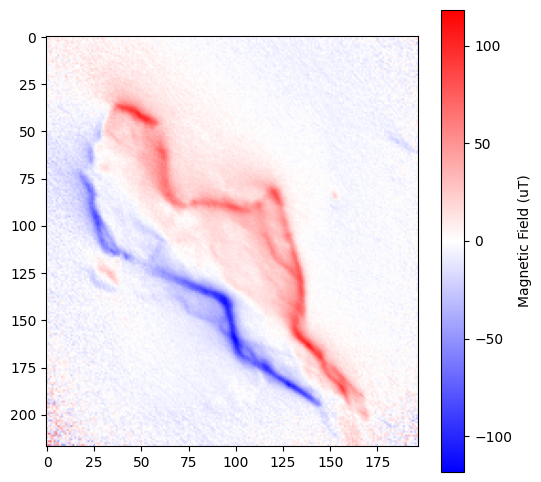

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Load data
dataPath='/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/data/Magnetisation in plane/CuCrP2S6_unimelb_measurement_72_Bnv.json'
PROP = LoadData(dataPath, ImageShape = 256, Normalise=True, Display=True)
plt.savefig(save_dir + '1_input_magnetic_field.png', dpi=300, bbox_inches='tight')
plt.show()
# file = open(dataPath, "r")
# data = json.load(file)
# MagneticField = np.asarray(data['ExperimentMagneticField']['BNV']['Data'])

# Update some of the options
PROP.options['Magnetisation']['Theta']= 70
PROP.options['Magnetisation']['FindTheta']= False
PROP.options['Magnetisation']['Phi'] = -45
PROP.options['Magnetisation']['FindPhi']= False


In [7]:
# Make the neural network
Generator = generator_CNN(Size=1, ImageSize=PROP.options['ImageShape']).to(device)

In [8]:
# Set the machine learning paramaters for keyword unpacking
ML_options = dict()
ML_options['mlp']=False
ML_options['LossFunction']='L1'
ML_options['Magnetization']=None
ML_options['IntegerOnly']=False
ML_options['PositiveMagnetisationOnly']=True
ML_options['PrintLossValue']=False
ML_options['Epochs']= 300

  0%|          | 0/300 [00:00<?, ?it/s]/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Propagator.py:374: RuntimeWarning: invalid value encountered in divide
  [-(kx ** 2) / k, -(kx * ky) / k, -1j * kx],
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Propagator.py:375: RuntimeWarning: invalid value encountered in divide
  [-kx * ky / k, -(ky ** 2 / k), -1j * ky],
100%|██████████| 300/300 [00:56<00:00,  5.32it/s]
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Train.py:249: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Train.py:256: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.lege

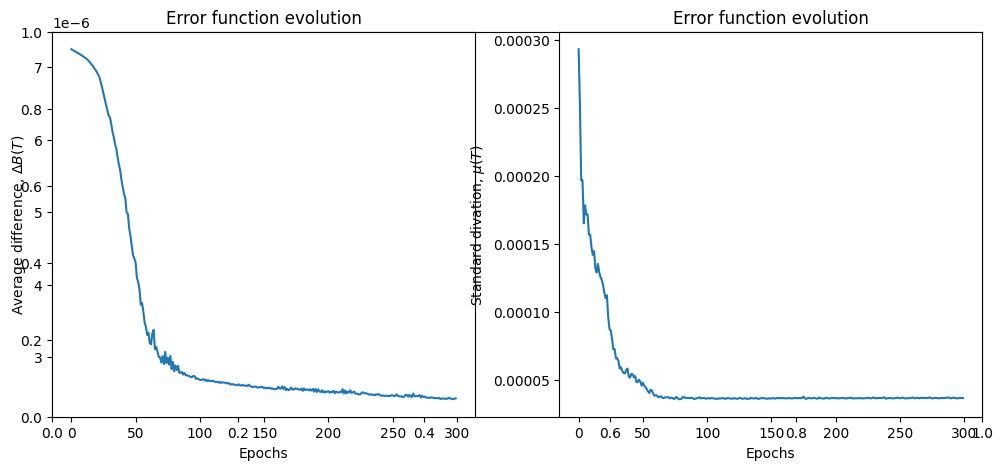

In [9]:
# Train the network
CNN_training = Magnetisation_CNN_training(device, Generator, PROP,ML_options)
bnv_cnn = CNN_training.train_cnn(**ML_options)
plt.savefig(save_dir + '2_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

Final MagnetisationMap shape: (256, 256)
Final ReconstructedBnv shape: (256, 256)


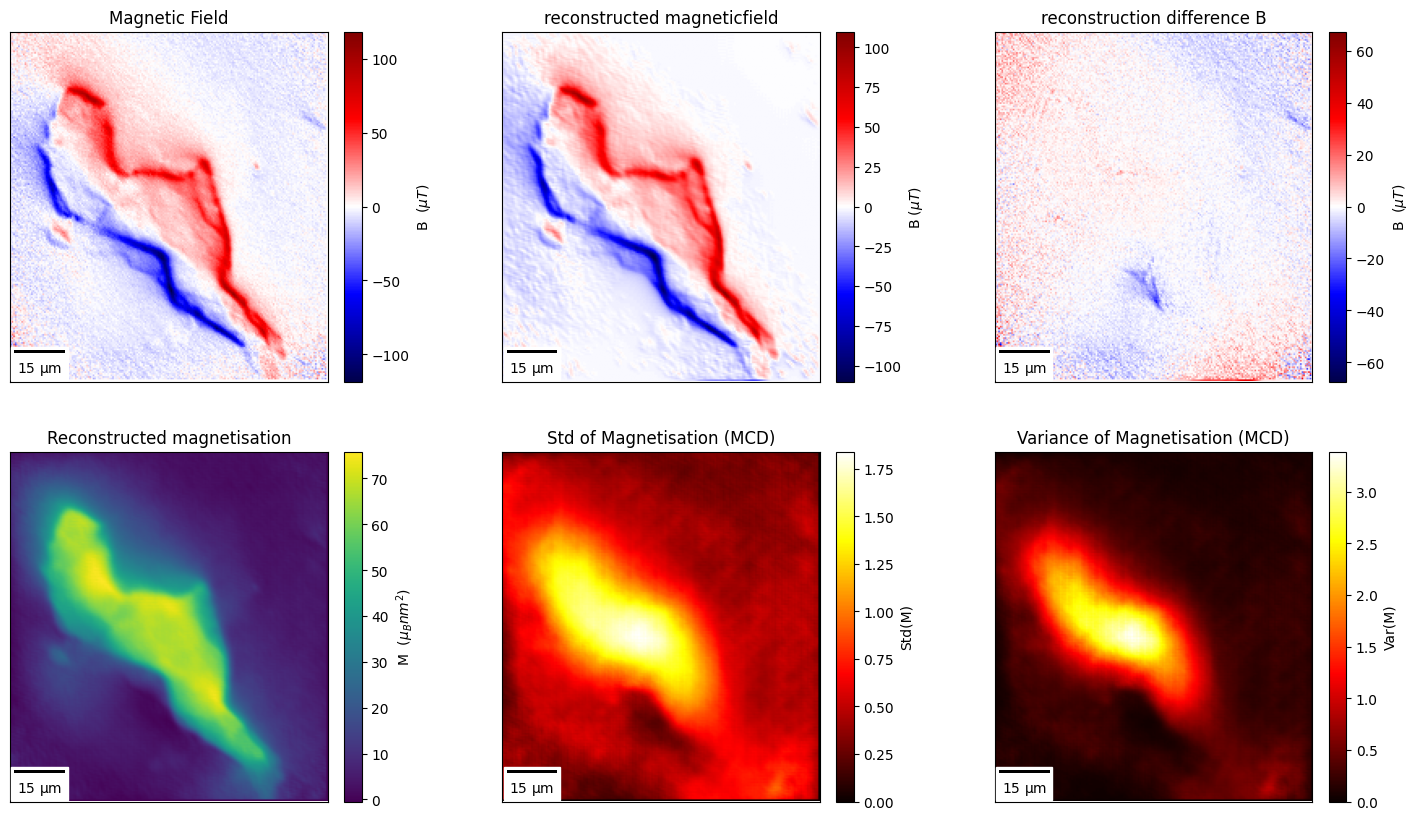

In [10]:
# Get the results and plot
Results = CNN_training.extract_results(plotResults = True)
plt.savefig(save_dir + '3_reconstruction_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from Magnetisation.utils import SaveDictToJson
# SaveDictToJson("B_Reconstruction_dataset_72_mlp", Results)